📈 'Predictive Analytics for Stock Market Trends'

In [59]:
# Install & Import libraries

In [60]:
!pip install yfinance --quiet

In [61]:
import yfinance as yf

In [62]:
import pandas as pd

In [63]:
import numpy as np

In [64]:
import matplotlib.pyplot as plt

In [65]:
from sklearn.model_selection import train_test_split

In [66]:
from sklearn.linear_model import LinearRegression

In [67]:
from sklearn.metrics import mean_squared_error

In [68]:
# Download Google Stock Data (GOOGL)

In [69]:
data = yf.download("GOOGL", start="2020-01-01" , end="2024-12-31")

/tmp/ipython-input-69-3291359124.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("GOOGL", start="2020-01-01" , end="2024-12-31")
[*********************100%***********************]  1 of 1 completed


In [70]:
data = data[['Close']] # Use only the 'Close' price

In [71]:
data.dropna(inplace=True)

In [72]:
# Prepare Data for Forecasting

In [73]:
data['Prediction'] = data [['Close']].shift(-30) # Predict 30 days into the future

In [74]:
# Features and labels

In [75]:
X = np.array(data[['Close']][:-30]) # Remove last 30 rows

In [76]:
y = np.array(data['Prediction'][:-30])

In [77]:
# Split into Training and Testing Sets

In [78]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [79]:
# Train Linear Regression Model

In [80]:
model = LinearRegression()

In [81]:
model.fit(X_train, y_train)

LinearRegression()

In [82]:
# Predict on Testing Data

In [83]:
predictions = model.predict(X_test)

In [84]:
# Evaluate Model Performance

In [85]:
mse = mean_squared_error(y_test, predictions)

In [86]:
print(f"Mean Squared Error: {mse:.2f}")

Mean Squared Error: 101.63


In [87]:
# Visualize Actual vs Predicted Prices (in INR)

In [88]:
# Convert USD predictions to INR

In [89]:
usd_to_inr_rate = 83 # Approximate exchange rate

In [90]:
y_test_inr = y_test * usd_to_inr_rate

In [91]:
predictions_inr = predictions * usd_to_inr_rate

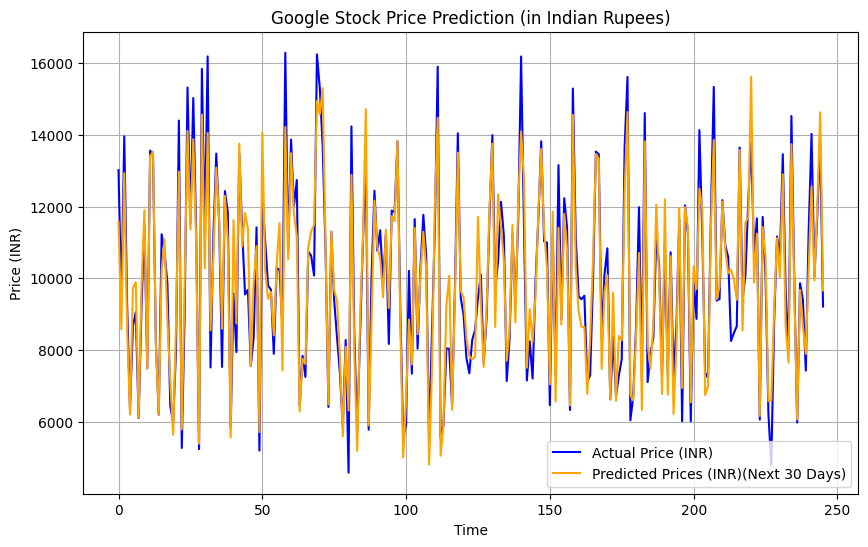

In [92]:
plt.figure(figsize=(10, 6))
line1, = plt.plot(y_test_inr, label='Actual Price (INR)', color='blue')
line2, = plt.plot(predictions_inr, label='Predicted Prices (INR)', color='orange')
plt.title("Google Stock Price Prediction (in Indian Rupees)")
plt.xlabel("Time")
plt.ylabel("Price (INR)")
plt.grid(True)
plt.legend(handles=[line1, line2], labels=['Actual Price (INR)', 'Predicted Prices (INR)(Next 30 Days)'])
plt.show()

In [93]:
# Predict Future Prices (Next 30 Days)

In [94]:
future_X = np.array(data['Close'][-30:])

In [95]:
future_prediction_usd = model.predict(future_X)

In [96]:
future_prediction_inr = future_prediction_usd * usd_to_inr_rate

In [97]:
# Plot Future Predictions (in INR)

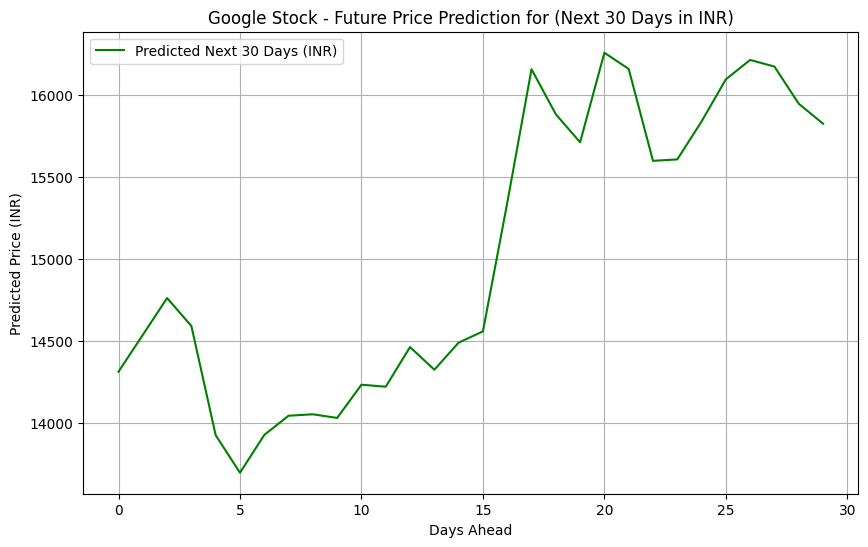

In [98]:
plt.figure(figsize=(10, 6))
line3, = plt.plot(future_prediction_inr, label='Predicted Next 30 Days (INR)', color='green')
plt.title("Google Stock - Future Price Prediction for (Next 30 Days in INR)")
plt.xlabel("Days Ahead")
plt.ylabel("Predicted Price (INR)")
plt.grid(True)
plt.legend(handles=[line3], labels=['Predicted Next 30 Days (INR)'])
plt.show()

**Conclusion**

- Used Google stock data from 2020 - 2024.

- Focused only on the 'Close' prices for prediction.

- I built a simple linear regrssion model to predict the next day's stock price using past closing prices.

- Predicted the stock price for the next 30 days.

- Converted predicted prices from USD to INR.

- Visualized both actual vs predicted prices.

- Also plotted the future forecast in INR.

- The model gives a basic idea of trend, but isn't super accurate (because stock prices are influenced by many other factors).

- Tools used: Python, Pandas, Matplotlib, Scikit-learn, yfinance.

- This was my first hands-on data analytics project and I learned how to work with real-world data and build a predictive model.
